# RLHF Fine-Tuning of GPT-2

Reinforcement Learning from Human Feedback (RLHF) is one of the most effective ways to fine-tune a language model, as it directly accommodates user preferences. It is, however, also one of the most challenging: the dataset consists of nothing but a series of prompts and binary preference labels for pairs of responses, and fine-tuning a large language model on such a sparse signal is an almost impossible task. Without proper guidance, the model invariably finds a way to exploit the data without learning anything useful, and often destroys the pre-trained weights in the process.

Proximal Policy Optimization (PPO) is a technique designed to solve this problem. The training process is separated into three stages. First, a *reward model* is trained. This is a GPT-based model with a scalar output head that is trained directly on the RLHF dataset to score responses based on human preference. Next, another GPT-base model undergoes supervised fine-tuning, which turns it into the *reference model*. Through exposure to the prompt-response pairs in the dataset, the model familiarises itself with the types of prompts it will encounter and acquires the conversational nature necessary to produce appropriate responses. At this stage, the model is completely agnostic to the preference signal itself.

The PPO algorithm provides a stable way of fine-tuning the reference model using the reward model's scores. During this training loop, two models are trained simultaneously: the *policy model* and the *value model*. The policy model is initialised as a copy of the reference model and then undergoes additional fine-tuning. The value model is architecturally similar to the reward model but is trained dynamically to predict its scores. The reason for its inclusion is that raw rewards do not constitute a clean training signal, as they are dominated by the intrinsic difficulty of the prompts rather than the quality of the responses. The true signal is the advantage, computed via Generalised Advantage Estimation (GAE), which measures the excess of the reward model's score over the value model's baseline estimate.

Even with the value model providing a baseline, the policy model will quickly drift away from the reference model and collapse without additional supervision. This is addressed by a Kullback-Leibler (KL) penalty term that anchors the policy to the vicinity of the reference model. The end result of the training process is a policy model that generates responses scored significantly higher by the reward model while maintaining the coherence and versatility of the original language model.

In this project, we implement the entire pipeline described above from scratch rather than relying on pre-existing PPO implementations such as TRL. All the models have GPT-2 as their backbone. For training, we use the Anthropic HH-RLHF dataset, a collection of human preference judgments on assistant conversations. We implement and train all the models described above and demonstrate the score increase of the policy model over the reference model.

This project was completed on a 32 GB Apple M1 system. All tools used in this project are implemented from scratch in `utils.py`, located in the `src` directory. All the trained models can be found in the following Hugging Face repository:

[https://huggingface.co/AlexanderGTumanov/rlhf-gpt2](https://huggingface.co/AlexanderGTumanov/rlhf-gpt2)

In [1]:
import os
import sys
import copy
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import utils

from transformers import GPT2LMHeadModel

We download the `Anthropic/hh-rlhf` dataset and cache it in the `data` directory. Samples where either the accepted or rejected response exceeds 512 tokens are dropped. This removes a small tail of outliers, but since we only use 10% of the remaining data anyway, the loss is unimportant.

In [2]:
dataset = utils.load_data(max_length = 512, overwrite = False)

The resulting dataset has ~ 18,400 samples, with a median response length of 160 tokens.

## Reward model

Samples in `Anthropic/hh-rlhf` are structured as `\n\nHuman: <prompt>\n\nAssistant: <reply>`. The RewardDataset class tokenizes both the chosen and rejected replies using the GPT-2 tokenizer. When building the dataloaders, we only use 10% of the data (`subset_fraction = 0.1`) due to hardware limitations, then package it into dataloaders with 10% of the samples reserved for validation. For internal consistency, all models are trained on the same subset of samples, fixed by a shared random seed.

In [ ]:
train_loader, valid_loader = utils.prepare_reward_dataloaders(
    dataset,
    batch_size = 8,
    subset_fraction = 0.1,
    val_fraction = 0.1,
    max_length = 512,
    seed = 42
)

The reward model is a GPT-2 backbone with a scalar head projecting from the final token embedding. It is trained to maximize the score difference between chosen and rejected replies for a given prompt.

In [ ]:
reward_model = utils.RewardModel()
reward_model = utils.train_reward_model(
    reward_model,
    train_loader,
    valid_loader,
    epochs = 1,
    model_dir = "../model/reward",
    dropout = 0.1,
    lr = 2e-5,
    weight_decay = 0.01,
    warmup_steps = 200,
    max_grad_norm = 25
)

This model converges extremely fast, as it quickly learns the randomly initialized linear head. One epoch is sufficient to saturate the loss.

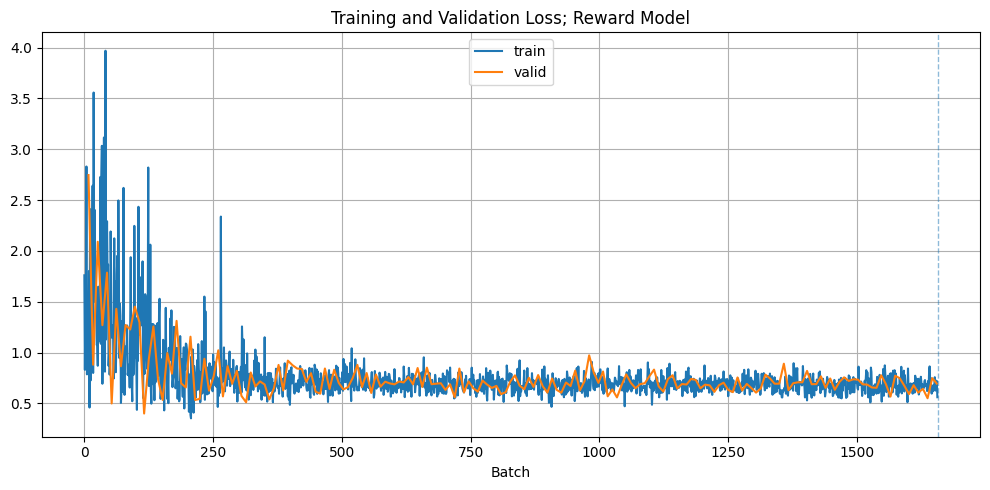

In [6]:
history = utils.load_history("../model/reward/history.pt")
utils.plot_history(history, log_x = False, log_y = False, batches_per_epoch = 1657, title = "Training and Validation Loss; Reward Model")

## Supervised Fine-Tuning (SFT)

We build the reference model via supervised fine-tuning: a freshly initialized GPT-2 with a language model head, trained to predict the chosen replies given the corresponding prompts.

In [ ]:
train_loader, valid_loader = utils.prepare_sft_dataloaders(
    dataset,
    batch_size = 8,
    subset_fraction = 0.1,
    val_fraction = 0.1,
    max_length = 512,
    seed = 42
)

In [ ]:
sft_model = GPT2LMHeadModel.from_pretrained("gpt2")
sft_model = utils.train_sft_model(
    sft_model,
    train_loader,
    valid_loader,
    epochs = 3,
    model_dir = "../model/sft",
    lr = 2e-5,
    weight_decay = 0.01,
    warmup_steps = 200,
    max_grad_norm = 15
)

The model was trained for three epochs to maximize the likelihood of generating the chosen reply given the prompt.

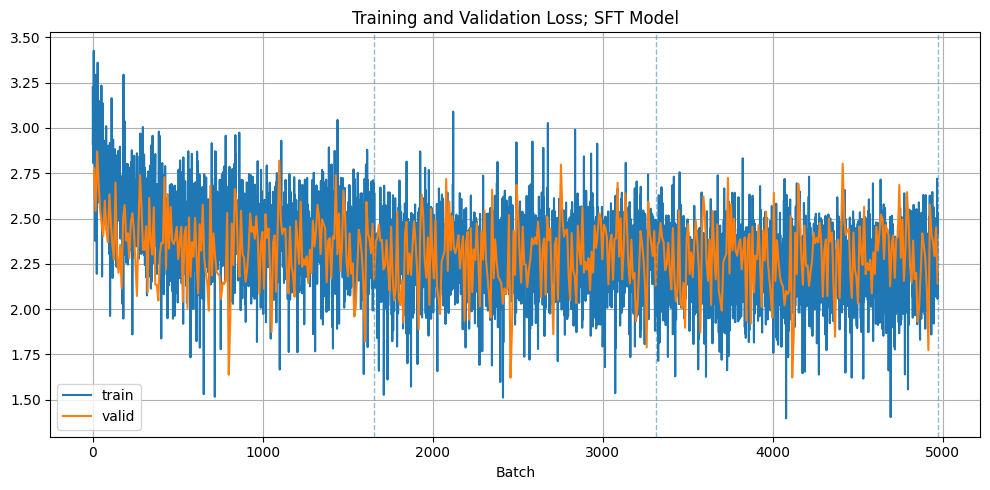

In [5]:
history = utils.load_history("../model/sft/history.pt")
utils.plot_history(history, log_x = False, log_y = False, batches_per_epoch = 1657, title = "Training and Validation Loss; SFT Model")

## PPO model

The `PPODataset` class records only the prompts from the original dataset; the responses are generated by the models at training time. The entire dataset is reserved for training, as there is no meaningful way to implement validation. Instead, the training process is monitored through other statistics — primarily the rewards assigned by the reward model, which tend to increase throughout training until saturation. Another important statistic to track is entropy, which serves as a reliable indicator of model collapse. For the GPT-2 model used in this project, the standard entropy benchmarks in nats are:

- entropy < 1:     the model has collapsed
- 2 < entropy < 3: healthy range for a fine-tuned model
- 3 < entropy < 5: typical range for a general GPT-2 language model
- entropy > 10:    white noise

Preventing entropy from collapsing below one nat is the most challenging aspect of the PPO training loop, and is the primary motivation behind the KL divergence penalty term.

In [9]:
ppo_loader = utils.prepare_ppo_dataloader(
    dataset,
    batch_size = 8,
    subset_fraction = 0.1,
    seed = 42
)

The training loop initializes the policy model as a deep copy of the reference model. The value model is also built on the SFT backbone, with an additional scalar head. Both are trained in tandem, each with its own optimizer, gradient clipping, and scheduler. Generation length is set to 160 tokens, which matches the median reply length in the original dataset.

One of the more useful features of the PPO algorithm is the `ppo_epochs` parameter: instead of performing a single update per batch, the loop reuses each batch of generated responses for multiple gradient steps. Most commercial implementations set it to 4; here it is set to 2 for added stability and lower hardware requirements.

Most other features of this loop are aimed at anchoring the policy model to the reference model and ensuring training stability. First, the `epsilon` parameter controls how much the policy is allowed to change in a single update by clamping the probability ratio between the updated and old policy to the range `[1 − ε, 1 + ε]`. Second, the KL penalty term is added to the loss function

$$\mathcal{L}_{\text{policy}} = \mathcal{L}_{\text{PPO}} + \beta \cdot D_{\text{KL}}$$

where $D_{\text{KL}}$ is the KL divergence between the policy and the reference distributions. It is implemented through the k3 estimator:

$$D_{\text{KL}} = e^{-d} + d - 1, \quad d = \log\frac{\pi_{\text{old}}}{\pi_{\text{ref}}}$$

Unlike the standard estimator, k3 is always non-negative and unbiased, which prevents runaway collapse when the log-ratio goes negative. Coefficient `beta` is adaptive: rather than fixing it, the training loop targets a specific KL value set by `target_kl`. That way, adjusting beta up or down each batch keeps the policy within a controlled distance of the reference model.

In [ ]:
reward_model = utils.load_model("../model/reward/model.pt")
sft_model = utils.load_model("../model/sft/model.pt")
policy_model = copy.deepcopy(sft_model)
value_model = utils.ValueModel(sft_model)
policy_model, value_model = utils.train_ppo_model(
    policy_model,
    value_model,
    sft_model,
    reward_model,
    ppo_loader,
    epochs = 1,
    ppo_epochs = 2,
    generation_length = 160,
    beta = 0.1,
    epsilon = 0.2,
    model_dir = "../model/ppo",
    lr_policy = 1e-6,
    lr_value = 1e-6,
    warmup_steps = 100,
    max_grad_norm_policy = 10,
    max_grad_norm_value = 100,
    target_kl = 0.05,
    kl_clamp = 10
)

The model was trained for one epoch; the training process is summarised by the following plots:

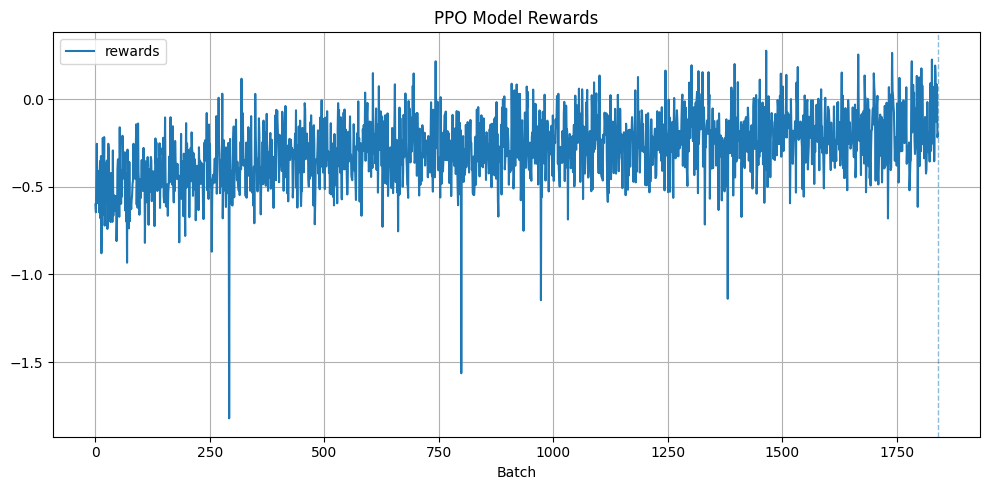

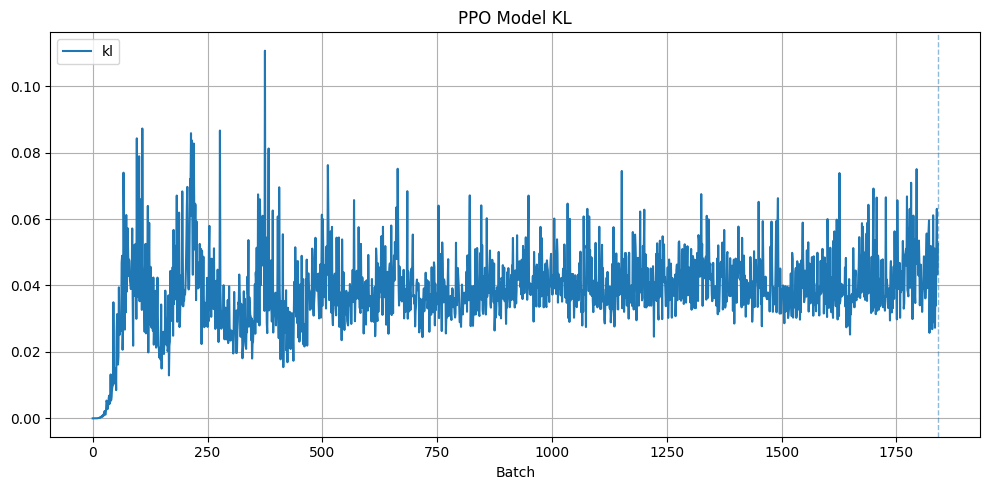

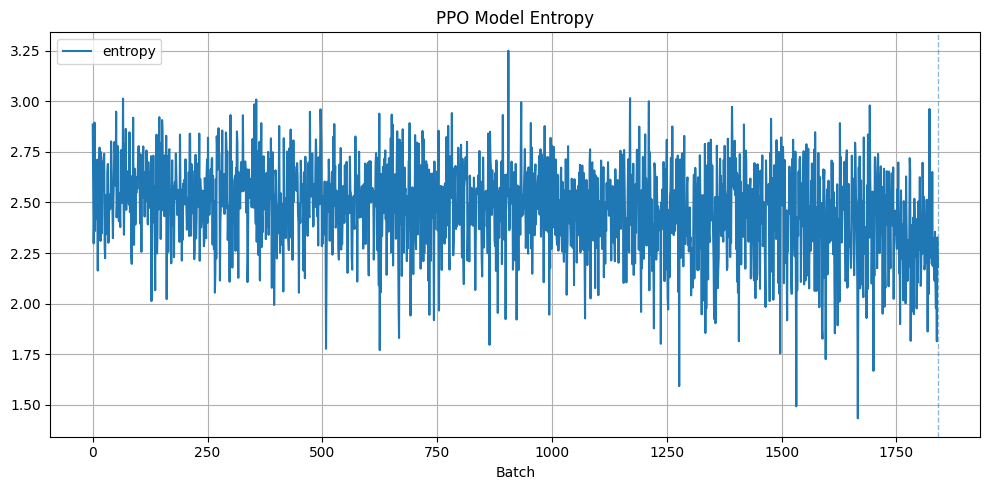

In [13]:
history = utils.load_history("../model/ppo/history.pt")
utils.plot_history(history, log_x = False, log_y = False, batches_per_epoch = 1841, title = "PPO Model Rewards", keys = ["rewards"])
utils.plot_history(history, log_x = False, log_y = False, batches_per_epoch = 1841, title = "PPO Model KL", keys = ["kl"])
utils.plot_history(history, log_x = False, log_y = False, batches_per_epoch = 1841, title = "PPO Model Entropy", keys = ["entropy"])

As can be seen in the rewards plot, the model has not quite reached full saturation, but as we will see shortly, it is already fully capable of significantly outperforming the reference model baseline.

KL divergence fluctuates early as `beta` is actively being adjusted, then stabilizes around batch 500 and gradually settles toward the target value of `target_kl = 0.05`.

Entropy remains firmly in the 2–3 nat range throughout, gently declining as the model grows more confident in its outputs.

Lastly, we compare the generation quality of the trained policy model against the reference model baseline as scored by the reward model. The policy improves mean reward by roughly 70% over the reference, a difference of ~17σ over the null. The `compare_models` function draws from the test split of the Anthropic HH-RLHF dataset, which was not seen by any of the models during training.


In [ ]:
reward_model = utils.load_model("../model/reward/model.pt")
sft_model = utils.load_model("../model/sft/model.pt")
policy_model = utils.load_model("../model/ppo/policy.pt")

utils.compare_models(dataset, reward_model, sft_model, policy_model, max_samples = 800, batch_size = 8, seed = 42)

Reference: -0.4560 ± 0.4313
Policy:    -0.1415 ± 0.4675
paired t-test: t = 16.886


## Conclusions

This project demonstrates a full RLHF pipeline applied to GPT-2, implemented from scratch. A reward model, a reference model, and a PPO training loop were built and trained on the Anthropic HH-RLHF dataset. The resulting policy model improves mean reward by ~70% over the reference baseline at ~17σ statistical significance, which demonstrates that a from-scratch RLHF implementation can produce measurable and significant improvement on a single personal machine.